In [1]:
import random
import numpy as np
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

In [2]:
# constantes
CAMINO = 0
PARED = 1
ORIGEN = 2
META = 3
VISITADO = 4
SOLUCION = 5

# Paleta de colores: [Blanco, Negro, Azul, Rojo, Celeste, Amarillo]
colores_laberinto = ListedColormap(['#FFFFFF', '#1A1A1A', '#007BFF', '#DC3545', '#AED6F1', '#F1C40F'])

# parametros
sys.setrecursionlimit(5000)
probabilidad_romper_pared=0.05
ANCHO = 200
ALTO = 200

In [3]:
"""
    Genera una matriz bidimensional que representa un laberinto aleatorio
    utilizando búsqueda en profundidad (DFS) con backtracking.

    Args:
        ancho (int): El número de columnas (se ajustará a impar).
        alto (int): El número de filas (se ajustará a impar).
        probabilidad_romper (float): probabilidad [0 a 1] de romper una pared en cada casilla

    Returns:
        list[list[int]]: Matriz con valores CAMINO, PARED, ORIGEN y META.
"""
def generar_laberinto(ancho, alto, probabilidad_romper):
    if ancho % 2 == 0: ancho += 1
    if alto % 2 == 0: alto += 1

    # Inicializar lleno de Paredes
    laberinto = [[PARED for _ in range(ancho)] for _ in range(alto)]

    def excavar(x, y):
        laberinto[y][x] = CAMINO
        direcciones = [(0, -2), (2, 0), (0, 2), (-2, 0)]
        random.shuffle(direcciones)

        for dx, dy in direcciones:
            nx, ny = x + dx, y + dy
            if 1 <= nx < ancho - 1 and 1 <= ny < alto - 1 and laberinto[ny][nx] == PARED:
                laberinto[y + dy // 2][x + dx // 2] = CAMINO
                excavar(nx, ny)

    # 1. Generar laberinto base (Perfecto)
    inicio_x = random.randrange(1, ancho, 2)
    inicio_y = random.randrange(1, alto, 2)
    excavar(inicio_x, inicio_y)

    # 2. Romper paredes aleatoriamente para crear ciclos (Caminos múltiples)
    for y in range(1, alto - 1):
        for x in range(1, ancho - 1):
            if laberinto[y][x] == PARED:
                # Solo romper si la pared separa dos caminos (evita áreas abiertas feas)
                # Revisar si hay caminos a los lados (horizontal o vertical)
                es_pared_horizontal = (laberinto[y][x-1] == CAMINO and laberinto[y][x+1] == CAMINO)
                es_pared_vertical = (laberinto[y-1][x] == CAMINO and laberinto[y+1][x] == CAMINO)

                if (es_pared_horizontal or es_pared_vertical) and random.random() < probabilidad_romper:
                    laberinto[y][x] = CAMINO

    # 3. Establecer Puntos de Interés
    laberinto[1][0] = ORIGEN
    laberinto[alto - 2][ancho - 1] = META

    return laberinto


"""
    Usa Matplotlib para renderizar la matriz del laberinto con colores personalizados y leyenda.
"""
def dibujar_laberinto_grafico(laberinto):
    # Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 10))

    # IMPORTANTE: vmax=5 para que reconozca los valores de VISITADO y SOLUCION
    # vmin=0 (Camino) hasta vmax=5 (Solución)
    img = ax.imshow(laberinto, cmap=colores_laberinto, interpolation='nearest', vmin=0, vmax=5)

    ax.axis('off')
    plt.title("Laberinto", fontsize=18, fontweight='bold', pad=20)

    # --- Leyenda Actualizada con 6 estados ---
    parches = [
        mpatches.Patch(color='#1A1A1A', label='Pared'),
        mpatches.Patch(color='#FFFFFF', label='Camino', ec='#CCCCCC'),
        mpatches.Patch(color='#007BFF', label='Origen'),
        mpatches.Patch(color='#DC3545', label='Meta'),
        mpatches.Patch(color='#AED6F1', label='Explorado'),
        mpatches.Patch(color='#F1C40F', label='Solución')
    ]

    ax.legend(handles=parches,
              loc='upper center',
              bbox_to_anchor=(0.5, -0.02),
              fancybox=True,
              shadow=True,
              ncol=3, # En dos filas de 3 queda más ordenado
              fontsize=11)

    plt.tight_layout()
    plt.show()

"""
    Encuentra las coordenadas (f, c) de un valor específico.
"""
def obtener_posicion(laberinto, valor):

    for f, fila in enumerate(laberinto):
        for c, celda in enumerate(fila):
            if celda == valor:
                return (f, c)
    return None

Generando y dibujando laberinto de 200x200...


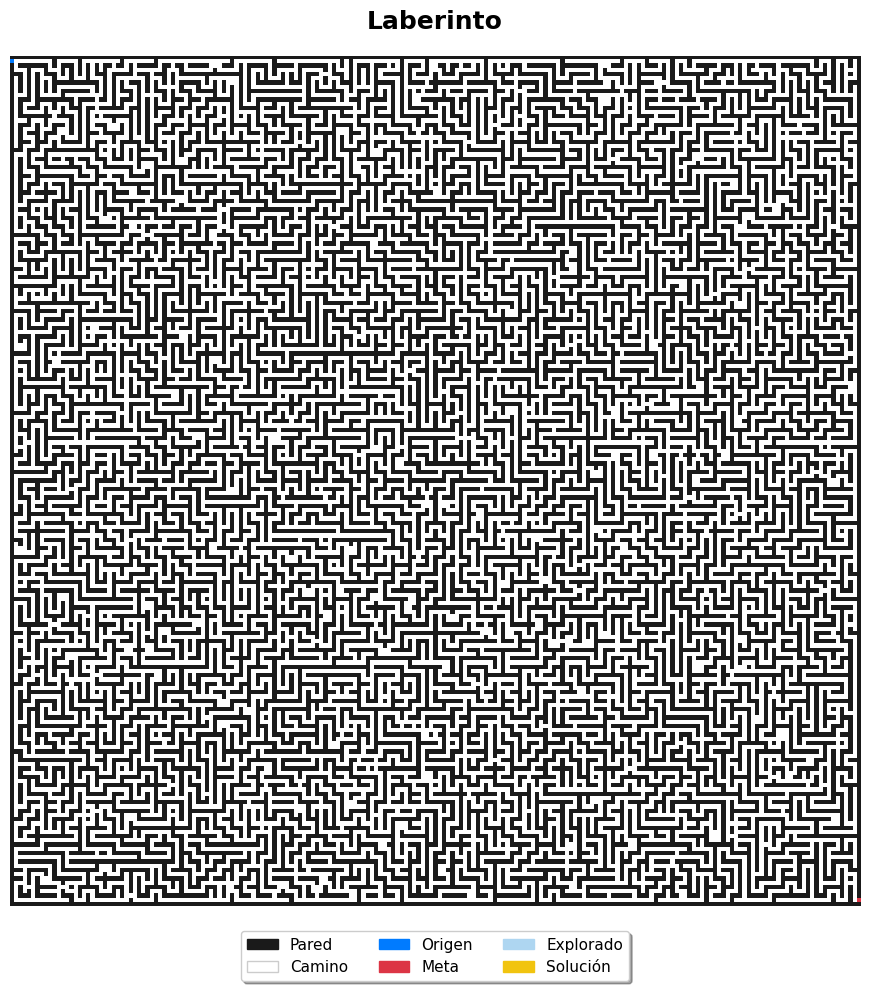

In [5]:
print(f"Generando y dibujando laberinto de {ANCHO}x{ALTO}...")
laberinto = generar_laberinto(ANCHO, ALTO, probabilidad_romper_pared)

# Llamamos a la nueva función gráfica
dibujar_laberinto_grafico(laberinto)

In [6]:
"""
    Convierte la matriz del laberinto en un diccionario de adyacencia.
    Solo conecta celdas que sean CAMINO, ORIGEN o META.
"""
def construir_grafo(laberinto):

    filas = len(laberinto)
    columnas = len(laberinto[0])
    laberinto_grafos = {}

    # Definir qué valores son transitables
    transitables = {CAMINO, ORIGEN, META}

    for f in range(filas):
        for c in range(columnas):
            # Si la celda actual es transitable, la agregamos al grafo
            if laberinto[f][c] in transitables:
                nodo_actual = (f, c)
                laberinto_grafos[nodo_actual] = []

                # Revisar las 4 direcciones adyacentes (Arriba, Abajo, Izquierda, Derecha)
                for df, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    nf, nc = f + df, c + dc

                    # Verificar que el vecino esté dentro de la matriz y sea transitable
                    if 0 <= nf < filas and 0 <= nc < columnas:
                        if laberinto[nf][nc] in transitables:
                            # Añadir el vecino a la lista de adyacencia
                            laberinto_grafos[nodo_actual].append((nf, nc))

    return laberinto_grafos

grafo = construir_grafo(laberinto)
print(f"Grafo generado con {len(grafo)} nodos transitables.")

Grafo generado con 20767 nodos transitables.


In [7]:
import time

def dfs(graph, start, end, laberinto_original):
    """
    Implementa el algoritmo de Búsqueda en Profundidad (DFS) para encontrar un camino en el laberinto.

    Args:
        graph (dict): El grafo de adyacencia del laberinto.
        start (tuple): Coordenadas (fila, columna) del nodo de inicio.
        end (tuple): Coordenadas (fila, columna) del nodo meta.
        laberinto_original (list[list[int]]): La matriz original del laberinto para visualización.

    Returns:
        tuple: (path, nodos_explorados, execution_time_ms, laberinto_solucion, laberinto_visitados)
               - path (list): Lista de nodos en el camino solución. None si no se encuentra.
               - nodos_explorados (int): Número total de nodos explorados.
               - execution_time_ms (float): Tiempo de ejecución en milisegundos.
               - laberinto_solucion (list[list[int]]): Laberinto con el camino solución resaltado.
               - laberinto_visitados (list[list[int]]): Laberinto con todos los nodos visitados resaltados.
    """
    start_time = time.perf_counter()
    pila = [(start, [start])] # Stack: (current_node, path_so_far)
    visitados = set()
    nodos_explorados = 0

    # Copia del laberinto para visualizar los nodos visitados
    laberinto_visitados_display = [row[:] for row in laberinto_original]

    while pila:
        current_node, path = pila.pop()

        if current_node not in visitados:
            visitados.add(current_node)
            nodos_explorados += 1

            # Marcar el nodo como VISITADO para la visualización de exploración
            if laberinto_visitados_display[current_node[0]][current_node[1]] == CAMINO:
                laberinto_visitados_display[current_node[0]][current_node[1]] = VISITADO

            if current_node == end:
                end_time = time.perf_counter()
                execution_time_ms = (end_time - start_time) * 1000 # en milisegundos

                # Copia del laberinto para visualizar la solución
                laberinto_solucion_display = [row[:] for row in laberinto_visitados_display]
                for r, c in path:
                    if laberinto_solucion_display[r][c] == VISITADO or laberinto_solucion_display[r][c] == CAMINO:
                        laberinto_solucion_display[r][c] = SOLUCION

                # Asegurar que el origen y la meta se muestren correctamente en la solución final
                laberinto_solucion_display[start[0]][start[1]] = ORIGEN
                laberinto_solucion_display[end[0]][end[1]] = META

                return path, nodos_explorados, execution_time_ms, laberinto_solucion_display, laberinto_visitados_display

            # Explorar vecinos
            for neighbor in graph.get(current_node, []):
                if neighbor not in visitados:
                    pila.append((neighbor, path + [neighbor]))

    # Si no se encuentra el camino después de explorar todo
    end_time = time.perf_counter()
    execution_time_ms = (end_time - start_time) * 1000
    return None, nodos_explorados, execution_time_ms, laberinto_visitados_display, laberinto_visitados_display # Retornar visited_display si no hay solución

Ejecutando DFS desde (1, 0) hasta (199, 200)...
--- Resultados DFS ---
Tiempo de ejecución: 363.9226 ms
Nodos explorados: 18779
Longitud del camino: 1321
Visualizando nodos explorados por DFS...


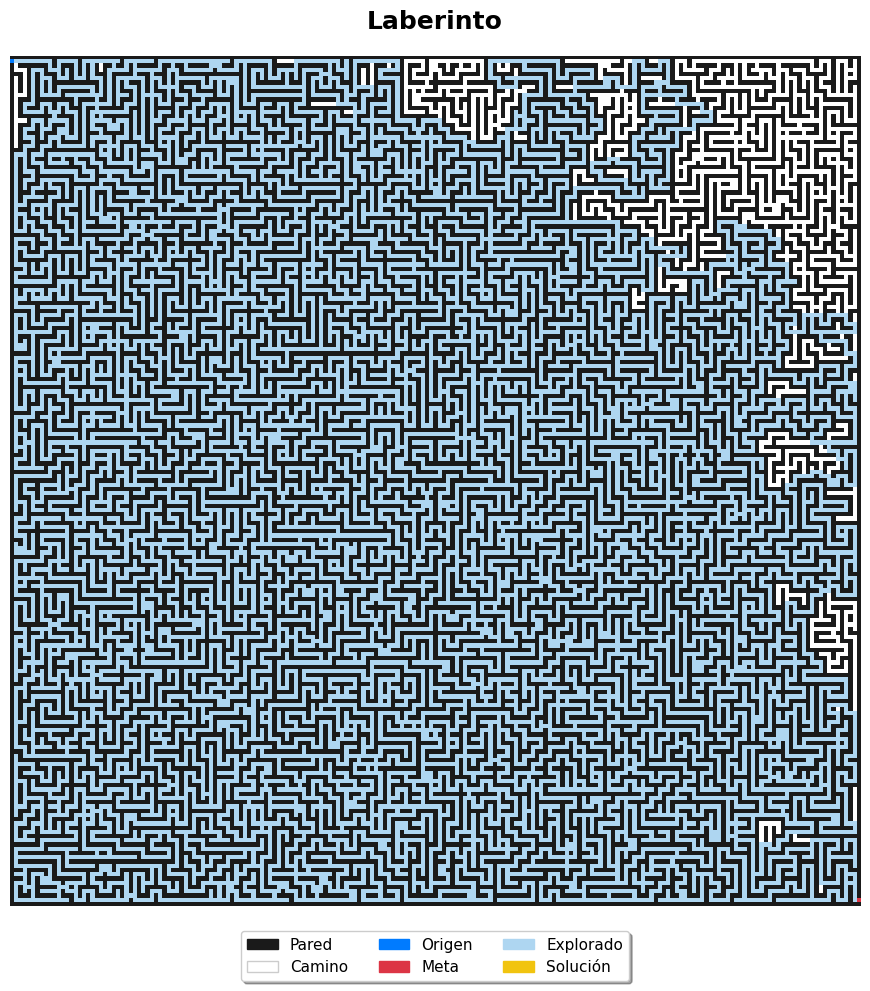

Visualizando camino solución DFS...


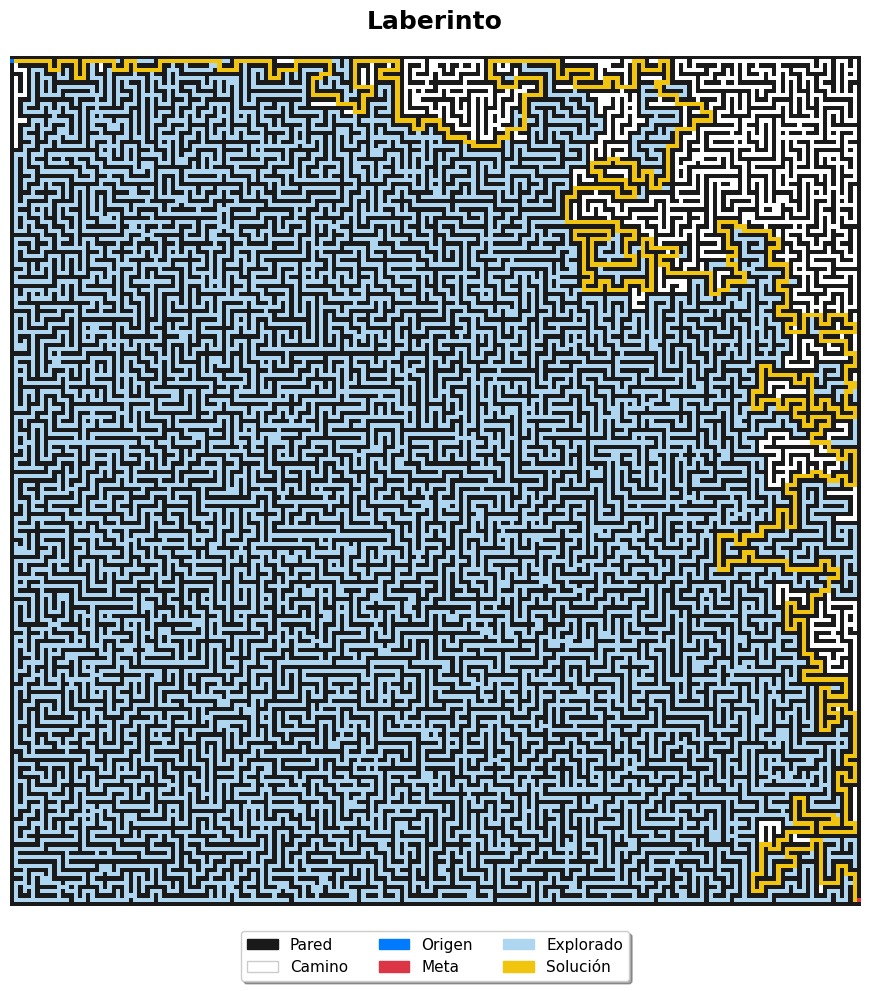

In [8]:
# Encontrar las posiciones de inicio y fin
origen_pos = obtener_posicion(laberinto, ORIGEN)
meta_pos = obtener_posicion(laberinto, META)

print(f"Ejecutando DFS desde {origen_pos} hasta {meta_pos}...")
path_dfs, nodos_dfs, tiempo_dfs, laberinto_solucion_dfs, laberinto_visitados_dfs = dfs(grafo, origen_pos, meta_pos, laberinto)

if path_dfs:
    print("--- Resultados DFS ---")
    print(f"Tiempo de ejecución: {tiempo_dfs:.4f} ms")
    print(f"Nodos explorados: {nodos_dfs}")
    print(f"Longitud del camino: {len(path_dfs)}")

    # Visualizar nodos explorados por DFS
    print("Visualizando nodos explorados por DFS...")
    dibujar_laberinto_grafico(laberinto_visitados_dfs)

    # Visualizar camino solución DFS
    print("Visualizando camino solución DFS...")
    dibujar_laberinto_grafico(laberinto_solucion_dfs)
else:
    print("No se encontró un camino con DFS.")

In [9]:
import collections # Para usar deque como una cola

def bfs(graph, start, end, laberinto_original):
    """
    Implementa el algoritmo de Búsqueda en Anchura (BFS) para encontrar un camino en el laberinto.

    Args:
        graph (dict): El grafo de adyacencia del laberinto.
        start (tuple): Coordenadas (fila, columna) del nodo de inicio.
        end (tuple): Coordenadas (fila, columna) del nodo meta.
        laberinto_original (list[list[int]]): La matriz original del laberinto para visualización.

    Returns:
        tuple: (path, nodos_explorados, execution_time_ms, laberinto_solucion, laberinto_visitados)
               - path (list): Lista de nodos en el camino solución. None si no se encuentra.
               - nodos_explorados (int): Número total de nodos explorados.
               - execution_time_ms (float): Tiempo de ejecución en milisegundos.
               - laberinto_solucion (list[list[int]]): Laberinto con el camino solución resaltado.
               - laberinto_visitados (list[list[int]]): Laberinto con todos los nodos visitados resaltados.
    """
    start_time = time.perf_counter()
    cola = collections.deque([(start, [start])]) # Queue: (current_node, path_so_far)
    visitados = {start}
    nodos_explorados = 0

    # Copia del laberinto para visualizar los nodos visitados
    laberinto_visitados_display = [row[:] for row in laberinto_original]

    while cola:
        current_node, path = cola.popleft()
        nodos_explorados += 1

        # Marcar el nodo como VISITADO para la visualización de exploración
        if laberinto_visitados_display[current_node[0]][current_node[1]] == CAMINO:
            laberinto_visitados_display[current_node[0]][current_node[1]] = VISITADO

        if current_node == end:
            end_time = time.perf_counter()
            execution_time_ms = (end_time - start_time) * 1000 # en milisegundos

            # Copia del laberinto para visualizar la solución
            laberinto_solucion_display = [row[:] for row in laberinto_visitados_display]
            for r, c in path:
                if laberinto_solucion_display[r][c] == VISITADO or laberinto_solucion_display[r][c] == CAMINO:
                    laberinto_solucion_display[r][c] = SOLUCION

            # Asegurar que el origen y la meta se muestren correctamente en la solución final
            laberinto_solucion_display[start[0]][start[1]] = ORIGEN
            laberinto_solucion_display[end[0]][end[1]] = META

            return path, nodos_explorados, execution_time_ms, laberinto_solucion_display, laberinto_visitados_display

        # Explorar vecinos
        for neighbor in graph.get(current_node, []):
            if neighbor not in visitados:
                visitados.add(neighbor)
                cola.append((neighbor, path + [neighbor]))

    # Si no se encuentra el camino después de explorar todo
    end_time = time.perf_counter()
    execution_time_ms = (end_time - start_time) * 1000
    return None, nodos_explorados, execution_time_ms, laberinto_visitados_display, laberinto_visitados_display # Retornar visited_display si no hay solución

Ejecutando BFS desde (1, 0) hasta (199, 200)...
--- Resultados BFS ---
Tiempo de ejecución: 98.6248 ms
Nodos explorados: 20672
Longitud del camino: 583
Visualizando nodos explorados por BFS...


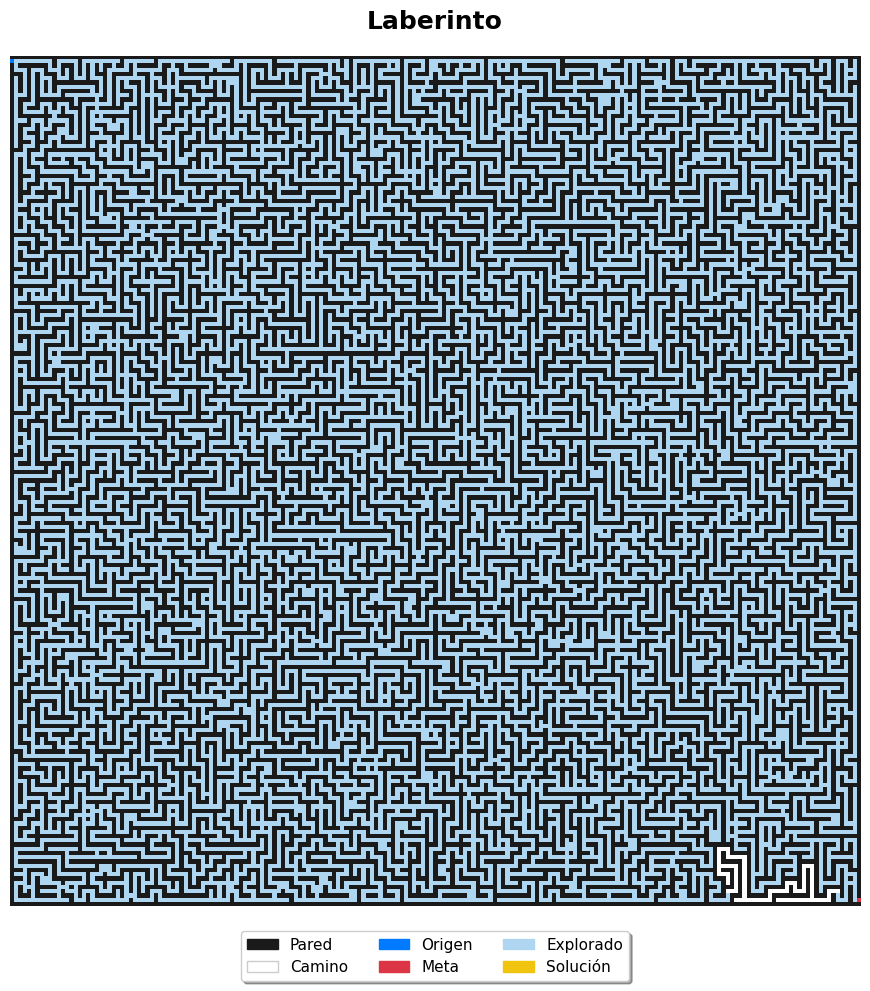

Visualizando camino solución BFS...


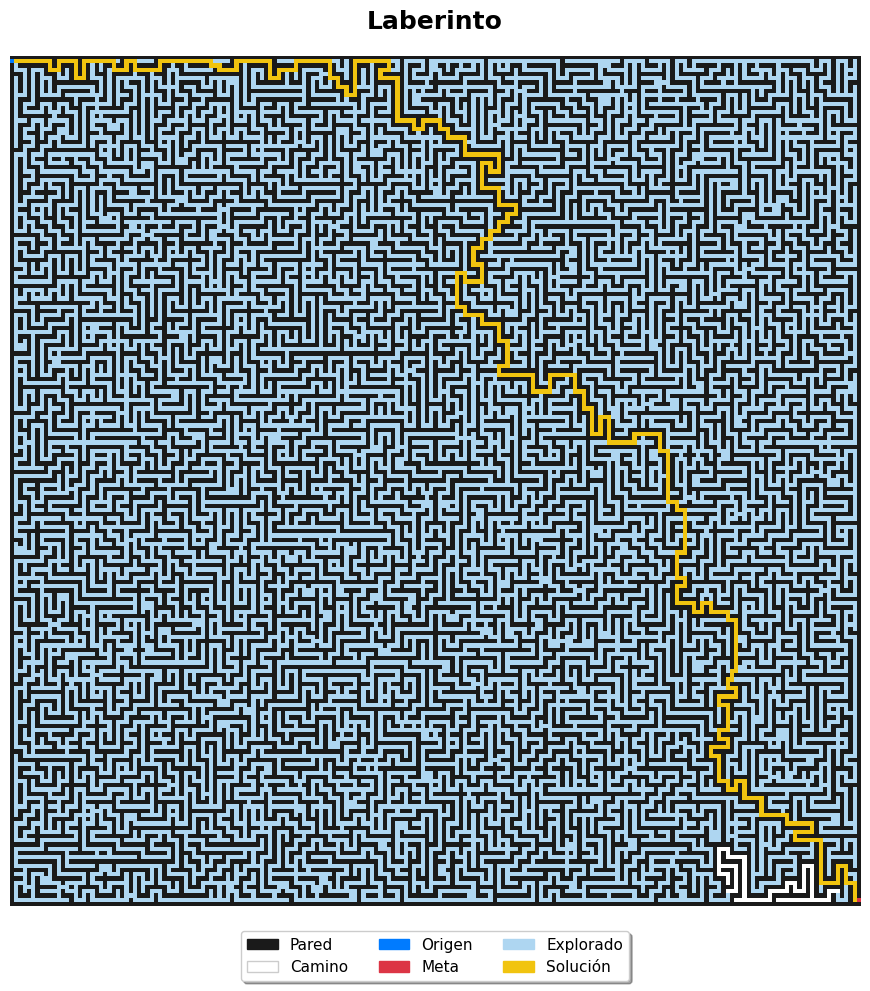

In [10]:
print(f"Ejecutando BFS desde {origen_pos} hasta {meta_pos}...")
path_bfs, nodos_bfs, tiempo_bfs, laberinto_solucion_bfs, laberinto_visitados_bfs = bfs(grafo, origen_pos, meta_pos, laberinto)

if path_bfs:
    print("--- Resultados BFS ---")
    print(f"Tiempo de ejecución: {tiempo_bfs:.4f} ms")
    print(f"Nodos explorados: {nodos_bfs}")
    print(f"Longitud del camino: {len(path_bfs)}")

    # Visualizar nodos explorados por BFS
    print("Visualizando nodos explorados por BFS...")
    dibujar_laberinto_grafico(laberinto_visitados_bfs)

    # Visualizar camino solución BFS
    print("Visualizando camino solución BFS...")
    dibujar_laberinto_grafico(laberinto_solucion_bfs)
else:
    print("No se encontró un camino con BFS.")

In [11]:
import heapq # Para usar una cola de prioridad (min-heap)

def dijkstra(graph, start, end, laberinto_original):
    """
    Implementa el algoritmo de Dijkstra para encontrar el camino más corto en el laberinto.

    Args:
        graph (dict): El grafo de adyacencia del laberinto.
        start (tuple): Coordenadas (fila, columna) del nodo de inicio.
        end (tuple): Coordenadas (fila, columna) del nodo meta.
        laberinto_original (list[list[int]]): La matriz original del laberinto para visualización.

    Returns:
        tuple: (path, nodos_explorados, execution_time_ms, laberinto_solucion, laberinto_visitados)
               - path (list): Lista de nodos en el camino solución. None si no se encuentra.
               - nodos_explorados (int): Número total de nodos explorados.
               - execution_time_ms (float): Tiempo de ejecución en milisegundos.
               - laberinto_solucion (list[list[int]]): Laberinto con el camino solución resaltado.
               - laberinto_visitados (list[list[int]]): Laberinto con todos los nodos visitados resaltados.
    """
    start_time = time.perf_counter()

    # (costo_acumulado, nodo_actual, camino_hasta_ahora)
    priority_queue = [(0, start, [start])]

    # Guarda el costo mínimo para llegar a cada nodo
    costos = {start: 0}

    # Guarda los nodos visitados para evitar ciclos y para visualización
    visitados = set()
    nodos_explorados = 0

    # Copia del laberinto para visualizar los nodos visitados
    laberinto_visitados_display = [row[:] for row in laberinto_original]

    while priority_queue:
        costo_actual, current_node, path = heapq.heappop(priority_queue)

        if current_node in visitados:
            continue

        visitados.add(current_node)
        nodos_explorados += 1

        # Marcar el nodo como VISITADO para la visualización de exploración
        if laberinto_visitados_display[current_node[0]][current_node[1]] == CAMINO:
            laberinto_visitados_display[current_node[0]][current_node[1]] = VISITADO

        if current_node == end:
            end_time = time.perf_counter()
            execution_time_ms = (end_time - start_time) * 1000

            # Copia del laberinto para visualizar la solución
            laberinto_solucion_display = [row[:] for row in laberinto_visitados_display]
            for r, c in path:
                if laberinto_solucion_display[r][c] == VISITADO or laberinto_solucion_display[r][c] == CAMINO:
                    laberinto_solucion_display[r][c] = SOLUCION

            # Asegurar que el origen y la meta se muestren correctamente en la solución final
            laberinto_solucion_display[start[0]][start[1]] = ORIGEN
            laberinto_solucion_display[end[0]][end[1]] = META

            return path, nodos_explorados, execution_time_ms, laberinto_solucion_display, laberinto_visitados_display

        # Explorar vecinos
        for neighbor in graph.get(current_node, []):
            # Asumimos que cada paso tiene un costo de 1
            nuevo_costo = costo_actual + 1

            if neighbor not in costos or nuevo_costo < costos[neighbor]:
                costos[neighbor] = nuevo_costo
                heapq.heappush(priority_queue, (nuevo_costo, neighbor, path + [neighbor]))

    # Si no se encuentra el camino
    end_time = time.perf_counter()
    execution_time_ms = (end_time - start_time) * 1000
    return None, nodos_explorados, execution_time_ms, laberinto_visitados_display, laberinto_visitados_display

Ejecutando Dijkstra desde (1, 0) hasta (199, 200)...
--- Resultados Dijkstra ---
Tiempo de ejecución: 189.1346 ms
Nodos explorados: 20672
Longitud del camino: 583
Visualizando nodos explorados por Dijkstra...


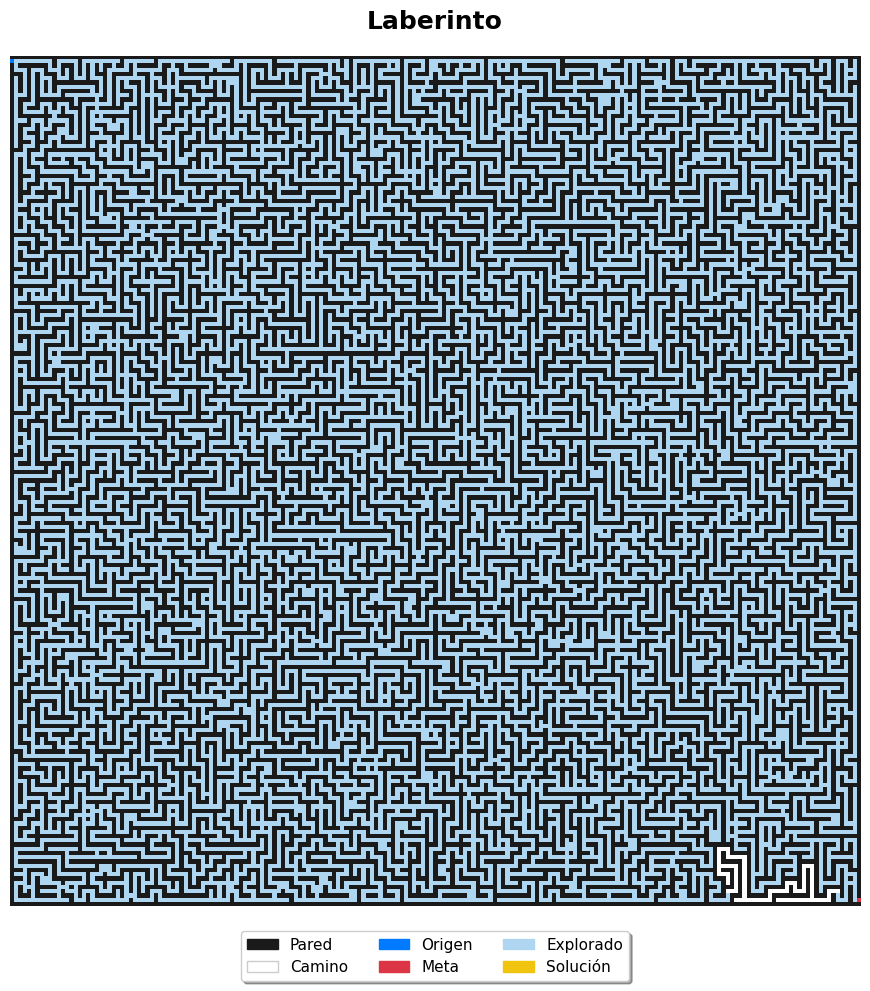

Visualizando camino solución Dijkstra...


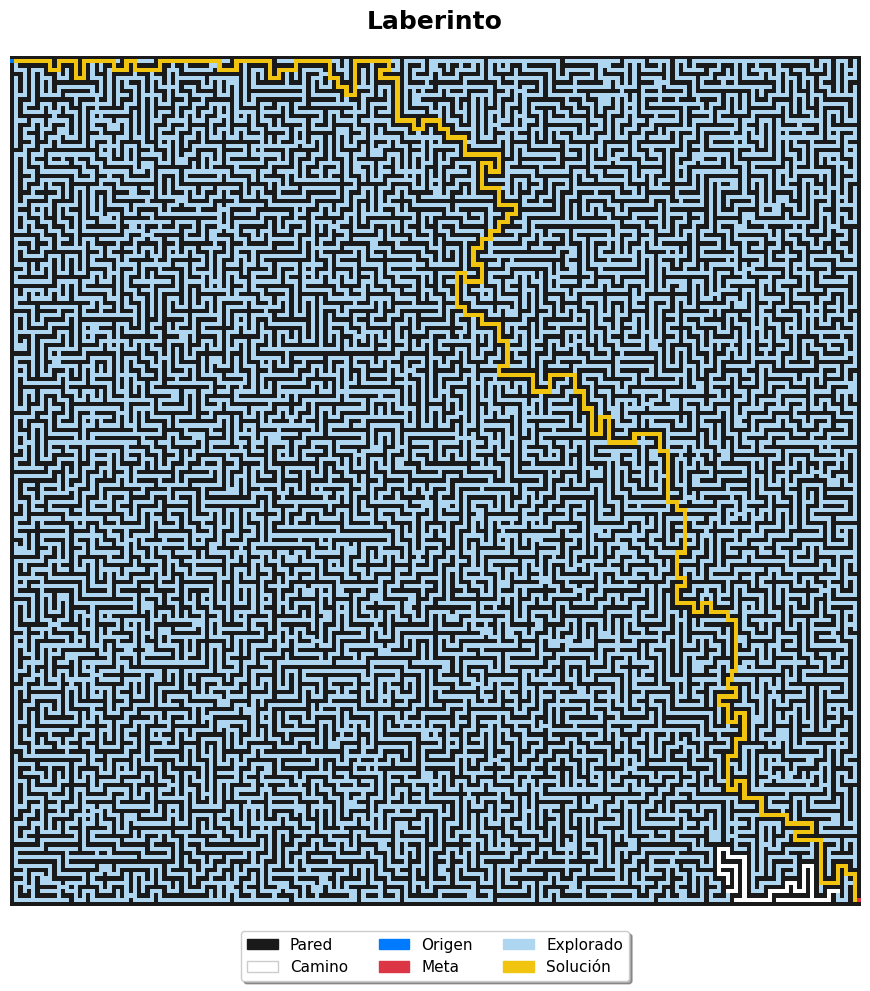

In [12]:
print(f"Ejecutando Dijkstra desde {origen_pos} hasta {meta_pos}...")
path_dijkstra, nodos_dijkstra, tiempo_dijkstra, laberinto_solucion_dijkstra, laberinto_visitados_dijkstra = dijkstra(grafo, origen_pos, meta_pos, laberinto)

if path_dijkstra:
    print("--- Resultados Dijkstra ---")
    print(f"Tiempo de ejecución: {tiempo_dijkstra:.4f} ms")
    print(f"Nodos explorados: {nodos_dijkstra}")
    print(f"Longitud del camino: {len(path_dijkstra)}")

    # Visualizar nodos explorados por Dijkstra
    print("Visualizando nodos explorados por Dijkstra...")
    dibujar_laberinto_grafico(laberinto_visitados_dijkstra)

    # Visualizar camino solución Dijkstra
    print("Visualizando camino solución Dijkstra...")
    dibujar_laberinto_grafico(laberinto_solucion_dijkstra)
else:
    print("No se encontró un camino con Dijkstra.")

In [13]:
def manhattan_distance(node1, node2):
    """
    Calcula la distancia de Manhattan entre dos nodos (celdas).
    """
    return abs(node1[0] - node2[0]) + abs(node1[1] - node2[1])

def a_star(graph, start, end, laberinto_original):
    """
    Implementa el algoritmo A* para encontrar el camino más corto en el laberinto.

    Args:
        graph (dict): El grafo de adyacencia del laberinto.
        start (tuple): Coordenadas (fila, columna) del nodo de inicio.
        end (tuple): Coordenadas (fila, columna) del nodo meta.
        laberinto_original (list[list[int]]): La matriz original del laberinto para visualización.

    Returns:
        tuple: (path, nodos_explorados, execution_time_ms, laberinto_solucion, laberinto_visitados)
               - path (list): Lista de nodos en el camino solución. None si no se encuentra.
               - nodos_explorados (int): Número total de nodos explorados.
               - execution_time_ms (float): Tiempo de ejecución en milisegundos.
               - laberinto_solucion (list[list[int]]): Laberinto con el camino solución resaltado.
               - laberinto_visitados (list[list[int]]): Laberinto con todos los nodos visitados resaltados.
    """
    start_time = time.perf_counter()

    # (f_cost, costo_acumulado, nodo_actual, camino_hasta_ahora)
    # f_cost = g_cost + h_cost
    priority_queue = [(0, 0, start, [start])]

    # g_cost: costo desde el inicio hasta el nodo actual
    g_costs = {start: 0}

    # Para evitar reprocesar nodos
    visitados = set()
    nodos_explorados = 0

    laberinto_visitados_display = [row[:] for row in laberinto_original]

    while priority_queue:
        f_cost, g_cost, current_node, path = heapq.heappop(priority_queue)

        if current_node in visitados:
            continue

        visitados.add(current_node)
        nodos_explorados += 1

        if laberinto_visitados_display[current_node[0]][current_node[1]] == CAMINO:
            laberinto_visitados_display[current_node[0]][current_node[1]] = VISITADO

        if current_node == end:
            end_time = time.perf_counter()
            execution_time_ms = (end_time - start_time) * 1000

            laberinto_solucion_display = [row[:] for row in laberinto_visitados_display]
            for r, c in path:
                if laberinto_solucion_display[r][c] == VISITADO or laberinto_solucion_display[r][c] == CAMINO:
                    laberinto_solucion_display[r][c] = SOLUCION

            laberinto_solucion_display[start[0]][start[1]] = ORIGEN
            laberinto_solucion_display[end[0]][end[1]] = META

            return path, nodos_explorados, execution_time_ms, laberinto_solucion_display, laberinto_visitados_display

        for neighbor in graph.get(current_node, []):
            # Asumimos un costo de 1 por cada paso
            new_g_cost = g_cost + 1

            if neighbor not in g_costs or new_g_cost < g_costs[neighbor]:
                g_costs[neighbor] = new_g_cost
                h_cost = manhattan_distance(neighbor, end)
                new_f_cost = new_g_cost + h_cost
                heapq.heappush(priority_queue, (new_f_cost, new_g_cost, neighbor, path + [neighbor]))

    end_time = time.perf_counter()
    execution_time_ms = (end_time - start_time) * 1000
    return None, nodos_explorados, execution_time_ms, laberinto_visitados_display, laberinto_visitados_display

Ejecutando A* desde (1, 0) hasta (199, 200)...
--- Resultados A* ---
Tiempo de ejecución: 130.6709 ms
Nodos explorados: 16862
Longitud del camino: 583
Visualizando nodos explorados por A*...


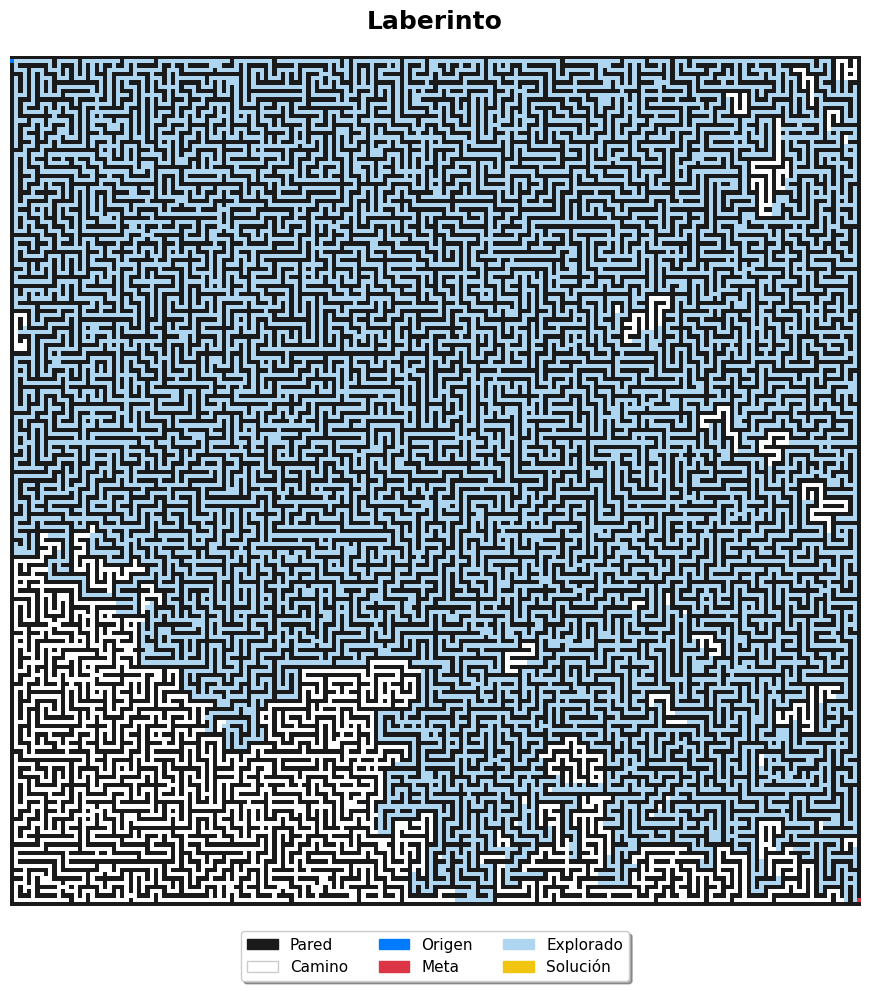

Visualizando camino solución A*...


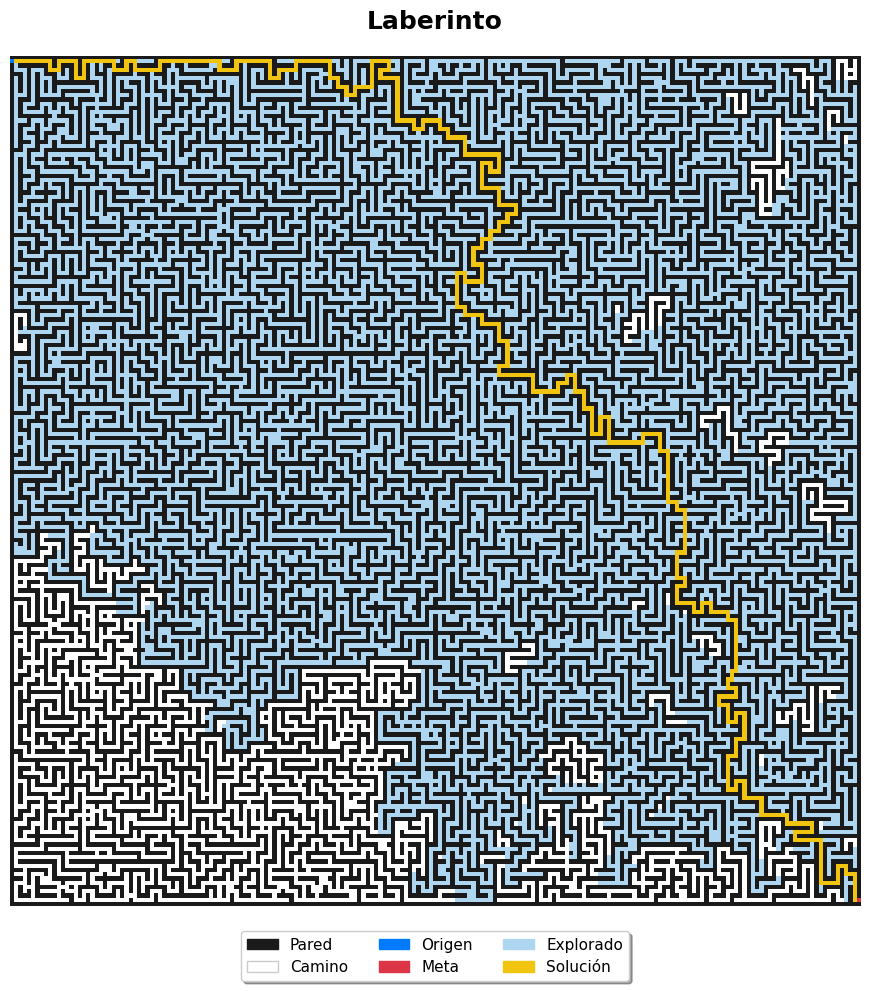

In [14]:
print(f"Ejecutando A* desde {origen_pos} hasta {meta_pos}...")
path_astar, nodos_astar, tiempo_astar, laberinto_solucion_astar, laberinto_visitados_astar = a_star(grafo, origen_pos, meta_pos, laberinto)

if path_astar:
    print("--- Resultados A* ---")
    print(f"Tiempo de ejecución: {tiempo_astar:.4f} ms")
    print(f"Nodos explorados: {nodos_astar}")
    print(f"Longitud del camino: {len(path_astar)}")

    # Visualizar nodos explorados por A*
    print("Visualizando nodos explorados por A*...")
    dibujar_laberinto_grafico(laberinto_visitados_astar)

    # Visualizar camino solución A*
    print("Visualizando camino solución A*...")
    dibujar_laberinto_grafico(laberinto_solucion_astar)
else:
    print("No se encontró un camino con A*.")

In [17]:
import pandas as pd

resultados = pd.DataFrame({
    "Algoritmo": ["DFS", "BFS", "Dijkstra", "A*"],
    "Tiempo (ms)": [tiempo_dfs, tiempo_bfs, tiempo_dijkstra, tiempo_astar],
    "Nodos visitados": [nodos_dfs, nodos_bfs, nodos_dijkstra, nodos_astar],
    "Longitud camino": [len(path_dfs), len(path_bfs), len(path_dijkstra), len(path_astar)]
})

print(resultados)

  Algoritmo  Tiempo (ms)  Nodos visitados  Longitud camino
0       DFS   363.922606            18779             1321
1       BFS    98.624848            20672              583
2  Dijkstra   189.134602            20672              583
3        A*   130.670919            16862              583


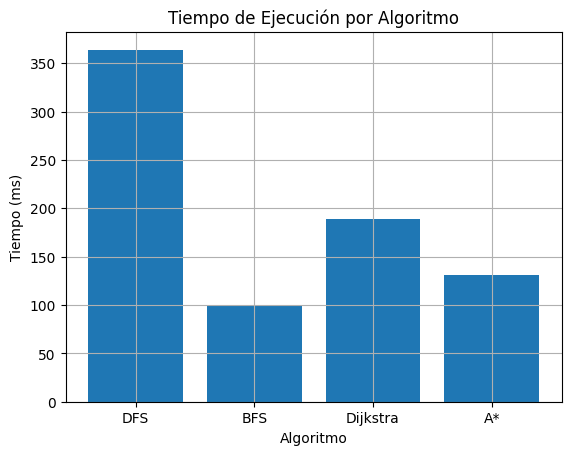

In [18]:
plt.figure()
plt.bar(resultados["Algoritmo"], resultados["Tiempo (ms)"])
plt.title("Tiempo de Ejecución por Algoritmo")
plt.xlabel("Algoritmo")
plt.ylabel("Tiempo (ms)")
plt.grid()
plt.show()

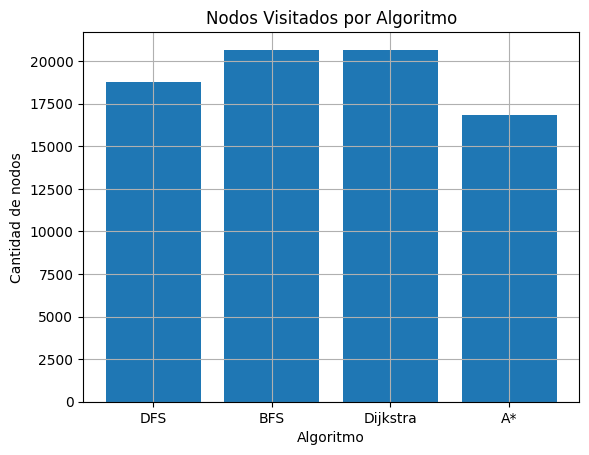

In [19]:
plt.figure()
plt.bar(resultados["Algoritmo"], resultados["Nodos visitados"])
plt.title("Nodos Visitados por Algoritmo")
plt.xlabel("Algoritmo")
plt.ylabel("Cantidad de nodos")
plt.grid()
plt.show()

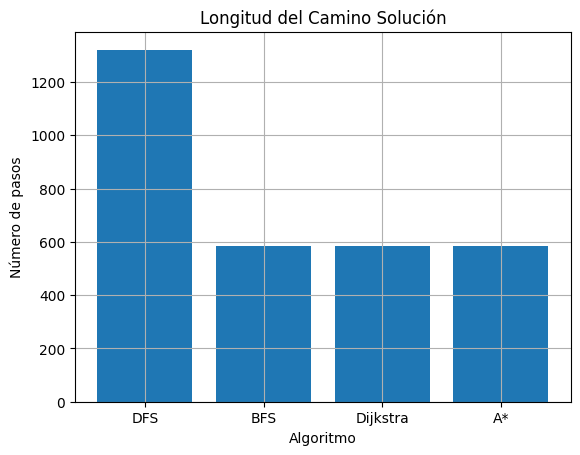

In [20]:
plt.figure()
plt.bar(resultados["Algoritmo"], resultados["Longitud camino"])
plt.title("Longitud del Camino Solución")
plt.xlabel("Algoritmo")
plt.ylabel("Número de pasos")
plt.grid()
plt.show()